In [20]:


import getpass
import os
from langchain_core.messages import AIMessage, BaseMessage,ToolMessage
from typing import List
from dotenv import load_dotenv
import datetime
import json
import random
from collections import defaultdict
from typing import List
from pydantic import BaseModel, Field
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.utilities.tavily_search import TavilySearchAPIWrapper
from langchain_core.messages import AIMessage, BaseMessage, ToolMessage, HumanMessage
from langgraph.prebuilt import ToolInvocation, ToolExecutor, ToolNode
from langchain_core.tools import StructuredTool
from chains import parser
from langgraph.graph import END, MessageGraph

from typing import List

from langchain_core.output_parsers.openai_tools import (
    PydanticToolsParser, # Parse raw text to JSON and validate that it matches a given Pydantic schema.
    JsonOutputToolsParser, # Just parse raw text to JSON (dictionary, list, etc.).
)

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

from pydantic import ValidationError

from typing import Literal

from langgraph.graph import END, StateGraph, START
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict

In [3]:

from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4-turbo-preview")
# parser = JsonOutputToolsParser(return_id=True)

In [4]:
search = TavilySearchAPIWrapper()
tavily_tool = TavilySearchResults(api_wrapper=search, max_results=5)


In [7]:

class Reflection(BaseModel):
    missing: str = Field(description="Critique of what is missing.")
    superfluous: str = Field(description="Critique of what is superfluous")


class AnswerQuestion(BaseModel):
    """Answer the question. Provide an answer, reflection, and then follow up with search queries to improve the answer."""

    answer: str = Field(description="~250 word detailed answer to the question.")
    reflection: Reflection = Field(description="Your reflection on the initial answer.")
    search_queries: list[str] = Field(
        description="1-3 search queries for researching improvements to address the critique of your current answer."
    )


class ResponderWithRetries:
    def __init__(self, runnable, validator):
        self.runnable = runnable
        self.validator = validator

    def respond(self, state: dict):
        response = []
        for attempt in range(3):
            response = self.runnable.invoke(
                {"messages": state["messages"]}, {"tags": [f"attempt:{attempt}"]}
            )
            try:
                self.validator.invoke(response)
                return {"messages": response}
            except ValidationError as e:
                state = state + [
                    response,
                    ToolMessage(
                        content=f"{repr(e)}\n\nPay close attention to the function schema.\n\n"
                        + self.validator.schema_json()
                        + " Respond by fixing all validation errors.",
                        tool_call_id=response.tool_calls[0]["id"],
                    ),
                ]
        return {"messages": response}

In [ ]:

actor_prompt_template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are expert researcher.
Current time: {time}

1. {first_instruction}
2. Reflect and critique your answer. Be severe to maximize improvement.
3. Recommend search queries to research information and improve your answer.""",
        ),
        MessagesPlaceholder(variable_name="messages"),
        (
            "user",
            "\n\n<system>Reflect on the user's original question and the"
            " actions taken thus far. Respond using the {function_name} function.</reminder>",
        ),
    ]
).partial(
    time=lambda: datetime.datetime.now().isoformat(),
)
initial_answer_chain = actor_prompt_template.partial(
    first_instruction="Provide a detailed ~250 word answer.",
    function_name=AnswerQuestion.__name__,
) | llm.bind_tools(tools=[AnswerQuestion])
validator = PydanticToolsParser(tools=[AnswerQuestion])

first_responder = ResponderWithRetries(
    runnable=initial_answer_chain, validator=validator
)


In [12]:

example_question = "Why is reflection useful in AI?"
initial = first_responder.respond(
    {"messages": [HumanMessage(content=example_question)]}
)


Revision

The second part of the actor is a revision step.

In [13]:
revise_instructions = """Revise your previous answer using the new information.
    - You should use the previous critique to add important information to your answer.
        - You MUST include numerical citations in your revised answer to ensure it can be verified.
        - Add a "References" section to the bottom of your answer (which does not count towards the word limit). In form of:
            - [1] https://example.com
            - [2] https://example.com
    - You should use the previous critique to remove superfluous information from your answer and make SURE it is not more than 250 words.
"""


# Extend the initial answer schema to include references.
# Forcing citation in the model encourages grounded responses
class ReviseAnswer(AnswerQuestion):
    """Revise your original answer to your question. Provide an answer, reflection,

    cite your reflection with references, and finally
    add search queries to improve the answer."""

    references: list[str] = Field(
        description="Citations motivating your updated answer."
    )


revision_chain = actor_prompt_template.partial(
    first_instruction=revise_instructions,
    function_name=ReviseAnswer.__name__,
) | llm.bind_tools(tools=[ReviseAnswer])
revision_validator = PydanticToolsParser(tools=[ReviseAnswer])

revisor = ResponderWithRetries(runnable=revision_chain, validator=revision_validator)

In [14]:
import json

revised = revisor.respond(
    {
        "messages": [
            HumanMessage(content=example_question),
            initial["messages"],
            ToolMessage(
                tool_call_id=initial["messages"].tool_calls[0]["id"],
                content=json.dumps(
                    tavily_tool.invoke(
                        {
                            "query": initial["messages"].tool_calls[0]["args"][
                                "search_queries"
                            ][0]
                        }
                    )
                ),
            ),
        ]
    }
)
revised["messages"]

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_lzsOji6LIqhDhnuCN0EQfEK6', 'function': {'arguments': '{"answer":"Reflection in AI, particularly in its ability to analyze and learn from past actions, is instrumental in enhancing adaptability, continuous learning, and explainability. For instance, Amazon’s recruitment tool, which discriminated based on gender, underscores the importance of reflection in minimizing biases and errors. Reflective mechanisms, if properly implemented, could have identified and mitigated these biases, showcasing how reflection can improve decision-making processes [1]. Furthermore, in the domain of sustainable foraging, the introduction of a reflective governor in a neuroevolutionary controller demonstrated how reflection facilitates adaptive and evolutionary behaviors in AI agents, reinforcing the significance of continuous learning [1]. Large Language Models (LLMs) also illustrate the potential of reflection in improving AI\'s understand


### Create Tool Node

Next, create a node to execute the tool calls. While we give the LLMs different schema names (and use those for validation), we want them both to route to the same tool.


In [15]:
from langchain_core.tools import StructuredTool

from langgraph.prebuilt import ToolNode


def run_queries(search_queries: list[str], **kwargs):
    """Run the generated queries."""
    return tavily_tool.batch([{"query": query} for query in search_queries])


tool_node = ToolNode(
    [
        StructuredTool.from_function(run_queries, name=AnswerQuestion.__name__),
        StructuredTool.from_function(run_queries, name=ReviseAnswer.__name__),
    ]
)


# Construct Graph

Now we can wire all our components together.

In [17]:

class State(TypedDict):
    messages: Annotated[list, add_messages]


MAX_ITERATIONS = 5
builder = StateGraph(State)
builder.add_node("draft", first_responder.respond)


builder.add_node("execute_tools", tool_node)
builder.add_node("revise", revisor.respond)
# draft -> execute_tools
builder.add_edge("draft", "execute_tools")
# execute_tools -> revise
builder.add_edge("execute_tools", "revise")

# Define looping logic:


def _get_num_iterations(state: list):
    i = 0
    for m in state[::-1]:
        if m.type not in {"tool", "ai"}:
            break
        i += 1
    return i


def event_loop(state: list):
    # in our case, we'll just stop after N plans
    num_iterations = _get_num_iterations(state["messages"])
    if num_iterations > MAX_ITERATIONS:
        return END
    return "execute_tools"


# revise -> execute_tools OR end
builder.add_conditional_edges("revise", event_loop, ["execute_tools", END])
builder.add_edge(START, "draft")
graph = builder.compile()

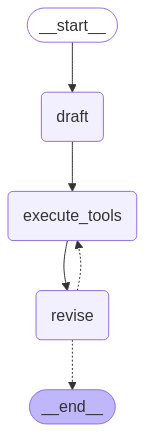

In [21]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [22]:


events = graph.stream(
    {"messages": [("user", "Write about AI-Powered SOC / autonomous soc  problem domain, list startups that do that and raised capital.")]},
    stream_mode="values",
)
for i, step in enumerate(events):
    print(f"Step {i}")
    step["messages"][-1].pretty_print()



Step 0
================================ Human Message =================================

HWrite about AI-Powered SOC / autonomous soc  problem domain, list startups that do that and raised capital.
Step 1
================================== Ai Message ==================================

AI-powered Security Operations Centers (SOC) or autonomous SOCs represent a transformative approach in cybersecurity management, aiming to enhance threat detection, response times, and overall security posture through the integration of artificial intelligence (AI) and machine learning algorithms. This domain addresses several problem areas within traditional SOC models, including the high volume of alerts, which can be overwhelming for human analysts; the complexity of modern cyber threat landscapes; and the scarcity of skilled cybersecurity professionals.

The primary challenges in developing and deploying AI-powered SOCs involve ensuring the accuracy and effectiveness of AI models in identifying genui